*Step 1 : Data Loading*

In [555]:
import pandas as pd 

df_cars=pd.read_csv("C:/Users/louis/Downloads/archive (23)/used_cars_data.csv")

C:\Users\louis\AppData\Local\Temp\ipykernel_55992\406826025.py:3: DtypeWarning: Columns (0: dealer_zip) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cars=pd.read_csv("C:/Users/louis/Downloads/archive (23)/used_cars_data.csv")


*Optional Step : Data Reduction*

In [556]:
df_cars = df_cars[df_cars["bed"].isna()]
df_cars = df_cars[df_cars["cabin"].isna()]
df_cars = df_cars[df_cars["frame_damaged"] != True]
df_cars = df_cars[df_cars["has_accidents"] != True]
df_cars = df_cars[df_cars["isCab"] != True]
df_cars = df_cars[~df_cars["main_picture_url"].isna()]
df_cars = df_cars[(df_cars["owner_count"].isna()) | (df_cars["owner_count"] == 1)]
df_cars = df_cars[df_cars["salvage"] != True]
df_cars = df_cars[df_cars["theft_title"] != True]
df_cars = df_cars[df_cars["daysonmarket"] < 365]

*Step 2 : Exploratory Data Analysis*

*1-Dataset Overview*

In [557]:
df_cars.head()

,vin,back_legroom,bed,bed_height,bed_length,body_type,cabin,city,city_fuel_economy,combine_fuel_economy,...,transmission,transmission_display,trimId,trim_name,vehicle_damage_category,wheel_system,wheel_system_display,wheelbase,width,year
1,SALCJ2FX1LH858117,38.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,...,A,9-Speed Automatic Overdrive,t86759,S AWD,NaN,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
3,SALRR2RV0L2433391,37.6 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,...,A,8-Speed Automatic Overdrive,t86074,V6 HSE AWD,NaN,AWD,All-Wheel Drive,115 in,87.4 in,2020
4,SALCJ2FXXLH862327,38.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,...,A,9-Speed Automatic Overdrive,t86759,S AWD,NaN,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
5,SALYK2EX1LA261711,37.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,...,A,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,NaN,AWD,All-Wheel Drive,113.1 in,84.4 in,2020
7,SALYK2EX5LA275434,37.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,...,A,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,NaN,AWD,All-Wheel Drive,113.1 in,84.4 in,2020


*3- Dataset Structure*

*3.1-Dataset Format*

In [558]:
df_cars.shape

(1814329, 66)

*3.2- Dataset Variable*

*3.2.1-Dataset Variable Types*

In [559]:
df_cars.dtypes

vin                       str
back_legroom              str
bed                       str
bed_height                str
bed_length                str
                        ...  
wheel_system              str
wheel_system_display      str
wheelbase                 str
width                     str
year                    int64
Length: 66, dtype: object

*3.2.2- Dataset Variable Structure*

*3.2.2.1-Dataset Quantitative Variables*

In [560]:
quantitative_columns=df_cars.select_dtypes(include="number").columns
quantitative_columns

Index(['city_fuel_economy', 'combine_fuel_economy', 'daysonmarket',
       'engine_displacement', 'highway_fuel_economy', 'horsepower',
       'is_certified', 'latitude', 'listing_id', 'longitude', 'mileage',
       'owner_count', 'price', 'savings_amount', 'seller_rating', 'sp_id',
       'vehicle_damage_category', 'year'],
      dtype='str')

*3.3.2-Dataset Qualitative Variables*

In [561]:
qualitative_columns=df_cars.select_dtypes(include=["object","category","string"]).columns
qualitative_columns

Index(['vin', 'back_legroom', 'bed', 'bed_height', 'bed_length', 'body_type',
       'cabin', 'city', 'dealer_zip', 'description', 'engine_cylinders',
       'engine_type', 'exterior_color', 'fleet', 'frame_damaged',
       'franchise_make', 'front_legroom', 'fuel_tank_volume', 'fuel_type',
       'has_accidents', 'height', 'interior_color', 'isCab', 'is_cpo',
       'is_oemcpo', 'length', 'listed_date', 'listing_color',
       'main_picture_url', 'major_options', 'make_name', 'maximum_seating',
       'model_name', 'power', 'salvage', 'sp_name', 'theft_title', 'torque',
       'transmission', 'transmission_display', 'trimId', 'trim_name',
       'wheel_system', 'wheel_system_display', 'wheelbase', 'width'],
      dtype='str')

*3.4- Dataset Information*

In [562]:
df_cars.info()

<class 'pandas.DataFrame'>
Index: 1814329 entries, 1 to 3000039
Data columns (total 66 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   vin                      str    
 1   back_legroom             str    
 2   bed                      str    
 3   bed_height               str    
 4   bed_length               str    
 5   body_type                str    
 6   cabin                    str    
 7   city                     str    
 8   city_fuel_economy        float64
 9   combine_fuel_economy     float64
 10  daysonmarket             int64  
 11  dealer_zip               object 
 12  description              str    
 13  engine_cylinders         str    
 14  engine_displacement      float64
 15  engine_type              str    
 16  exterior_color           str    
 17  fleet                    object 
 18  frame_damaged            object 
 19  franchise_dealer         bool   
 20  franchise_make           str    
 21  front_legroom           

*4-Dataset Missing Values*

*4.1-Dataset Missing Values Presence*

In [563]:
df_cars.isna().any()

vin                     False
back_legroom             True
bed                      True
bed_height               True
bed_length               True
                        ...  
wheel_system             True
wheel_system_display     True
wheelbase                True
width                    True
year                    False
Length: 66, dtype: bool

*4.2- Dataset Missing Values Count*

In [564]:
df_cars.isna().sum()

vin                           0
back_legroom              92671
bed                     1814329
bed_height              1558766
bed_length              1558766
                         ...   
wheel_system              89404
wheel_system_display      89404
wheelbase                 92671
width                     92671
year                          0
Length: 66, dtype: int64

*4.3-Dataset Missing Values Percentage*

*4.3.1-Dataset Quantitative Missing Values Percentage*

In [565]:
missing_values_percentage_quantitative=df_cars.select_dtypes(include="number").isna().mean().sort_values(ascending=False) * 100
missing_values_percentage_quantitative

combine_fuel_economy       100.000000
is_certified               100.000000
vehicle_damage_category    100.000000
owner_count                 66.599222
city_fuel_economy           15.043468
highway_fuel_economy        15.043468
horsepower                   5.848112
engine_displacement          5.848112
mileage                      5.080501
seller_rating                0.996346
sp_id                        0.001102
listing_id                   0.000000
latitude                     0.000000
daysonmarket                 0.000000
longitude                    0.000000
price                        0.000000
savings_amount               0.000000
year                         0.000000
dtype: float64

*4.3.2-Dataset Qualitative Missing Values Percentage*

In [566]:
missing_values_percentage_qualitative=df_cars.select_dtypes(include=["object", "category", "string"]).isna().mean().sort_values(ascending=False) * 100
missing_values_percentage_qualitative

bed                     100.000000
cabin                   100.000000
is_oemcpo                94.979576
is_cpo                   93.053244
bed_length               85.914186
bed_height               85.914186
has_accidents            62.680694
salvage                  62.680694
theft_title              62.680694
isCab                    62.680694
fleet                    62.680694
frame_damaged            62.680694
torque                   19.023397
power                    17.916155
interior_color            9.810790
franchise_make            8.857820
major_options             6.122870
maximum_seating           5.107729
length                    5.107729
height                    5.107729
front_legroom             5.107729
fuel_tank_volume          5.107729
back_legroom              5.107729
wheelbase                 5.107729
width                     5.107729
wheel_system              4.927662
wheel_system_display      4.927662
trim_name                 3.791484
trimId              

*4.3.2-Dataset Overall Missing Values Percentage*

In [567]:
missing_values_percentage_overall=df_cars.isna().mean().sort_values(ascending=False) * 100
missing_values_percentage_overall

cabin                      100.0
bed                        100.0
vehicle_damage_category    100.0
is_certified               100.0
combine_fuel_economy       100.0
                           ...  
latitude                     0.0
listing_color                0.0
sp_name                      0.0
savings_amount               0.0
year                         0.0
Length: 66, dtype: float64

*5-Dataset Duplicates Values*

*5.1- Dataset Duplicate Values Presence*

In [568]:
df_cars.duplicated().any()

np.True_

*5.2-Dataset Duplicate Values Count*

In [569]:
df_cars.duplicated().sum()

np.int64(20)

*5.3-Dataset Dataset Duplicate Values Percentage*

In [570]:
df_cars.duplicated().mean()*100

np.float64(0.001102335904899277)

*6-Dataset Statistics*

*6.1- ?????*

In [571]:
df_cars.describe()

,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_displacement,highway_fuel_economy,horsepower,is_certified,latitude,listing_id,longitude,mileage,owner_count,price,savings_amount,seller_rating,sp_id,vehicle_damage_category,year
count,1.541391e+06,0.0,1.814329e+06,1.708225e+06,1.541391e+06,1.708225e+06,0.0,1.814329e+06,1.814329e+06,1.814329e+06,1.722152e+06,606000.0,1.814329e+06,1.814329e+06,1.796252e+06,1.814309e+06,0.0,1.814329e+06
mean,2.336320e+01,NaN,7.679137e+01,2.845629e+03,2.996273e+01,2.462581e+02,NaN,3.693881e+01,2.755232e+08,-9.058349e+01,1.508637e+04,1.0,3.326311e+04,4.027834e+02,4.268049e+00,2.179267e+05,NaN,2.018875e+03
std,9.428403e+00,NaN,8.561693e+01,1.301749e+03,8.058095e+00,9.084264e+01,NaN,5.002098e+00,6.593205e+06,1.394395e+01,2.907274e+04,0.0,1.898445e+04,9.781588e+02,4.992622e-01,1.312727e+05,NaN,3.130724e+00
min,8.000000e+00,NaN,0.000000e+00,7.000000e+02,1.100000e+01,5.500000e+01,NaN,1.839880e+01,2.518374e+08,-1.578850e+02,0.000000e+00,1.0,2.990000e+02,0.000000e+00,1.000000e+00,4.159300e+04,NaN,1.915000e+03
25%,1.800000e+01,NaN,1.800000e+01,2.000000e+03,2.500000e+01,1.740000e+02,NaN,3.346010e+01,2.736020e+08,-9.706340e+01,5.000000e+00,1.0,2.199000e+04,0.000000e+00,4.016667e+00,6.111700e+04,NaN,2.018000e+03
50%,2.200000e+01,NaN,4.100000e+01,2.500000e+03,2.900000e+01,2.400000e+02,NaN,3.785040e+01,2.780568e+08,-8.705780e+01,1.200000e+01,1.0,2.913400e+04,0.000000e+00,4.333333e+00,2.777930e+05,NaN,2.020000e+03
75%,2.600000e+01,NaN,9.400000e+01,3.500000e+03,3.300000e+01,3.000000e+02,NaN,4.102010e+01,2.801670e+08,-8.037130e+01,2.218100e+04,1.0,4.096900e+04,3.950000e+02,4.600000e+00,3.182960e+05,NaN,2.020000e+03
max,1.270000e+02,NaN,3.640000e+02,8.400000e+03,1.270000e+02,9.490000e+02,NaN,4.892370e+01,2.820222e+08,-6.607850e+01,1.225238e+06,1.0,2.749950e+06,1.427380e+05,5.000000e+00,4.407980e+05,NaN,2.021000e+03


*6.2- Dataset Skewness*

In [572]:
df_cars.skew(numeric_only=True)

city_fuel_economy           5.886273
combine_fuel_economy             NaN
daysonmarket                1.494160
engine_displacement         1.234835
franchise_dealer           -2.927237
highway_fuel_economy        4.022724
horsepower                  0.759321
is_certified                     NaN
is_new                     -0.613591
latitude                   -0.340319
listing_id                 -1.515163
longitude                  -0.812322
mileage                     3.142901
owner_count                 0.000000
price                      12.916018
savings_amount             14.306511
seller_rating              -1.430089
sp_id                      -0.165377
vehicle_damage_category          NaN
year                      -10.483463
dtype: float64

*6.3 Dataset Kurtosis*

In [573]:
df_cars.kurt(numeric_only=True)

city_fuel_economy            54.811090
combine_fuel_economy               NaN
daysonmarket                  1.235588
engine_displacement           0.991596
franchise_dealer              6.568722
highway_fuel_economy         33.330066
horsepower                    0.373372
is_certified                       NaN
is_new                       -1.623508
latitude                     -0.771477
listing_id                    1.561328
longitude                    -0.296952
mileage                      20.172113
owner_count                   0.000000
price                      1030.725386
savings_amount             1045.669513
seller_rating                 4.459823
sp_id                        -1.571134
vehicle_damage_category            NaN
year                        187.305667
dtype: float64

*5 – Dataset Visualization*

*5.1 – Univariate Analysis*

*5.1.1-Univariate Analysis of Quantitative Variables*

<Axes: xlabel='price', ylabel='Count'>

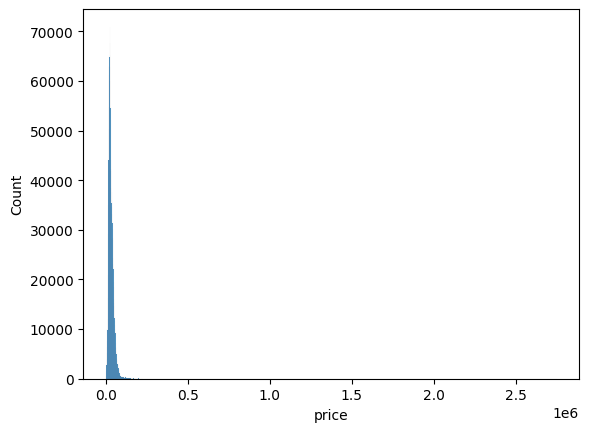

In [574]:
import seaborn as sns 

sns.histplot(x="price", data=df_cars)

<Axes: xlabel='mileage', ylabel='Count'>

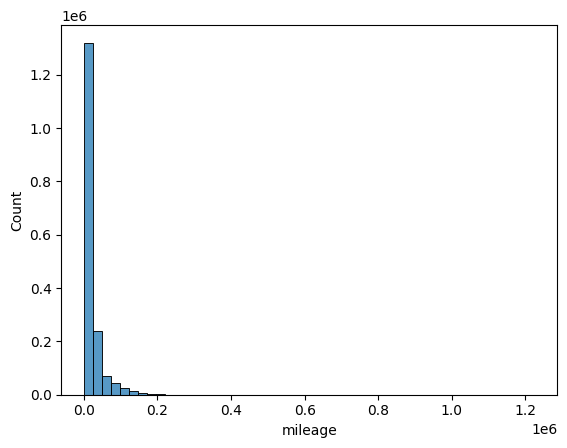

In [575]:
import seaborn as sns 
sns.histplot(x="mileage", data=df_cars, bins=50)

<Axes: xlabel='horsepower', ylabel='Count'>

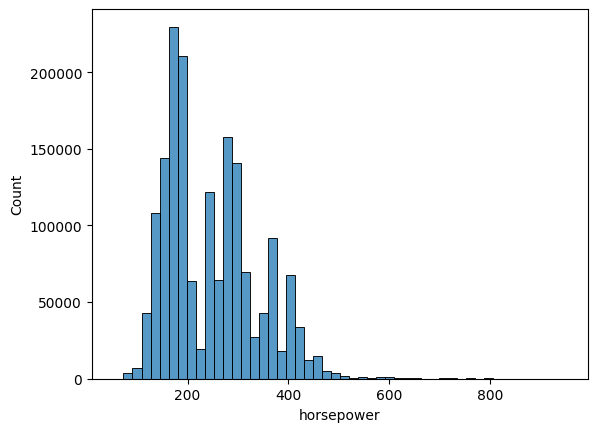

In [576]:
import seaborn as sns 

sns.histplot(x="horsepower",data=df_cars, bins=50)

<Axes: ylabel='price'>

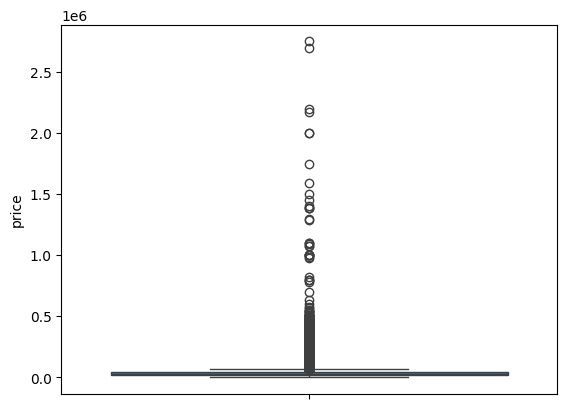

In [577]:
import seaborn as sns 

sns.boxplot(y="price", data=df_cars)

<Axes: ylabel='mileage'>

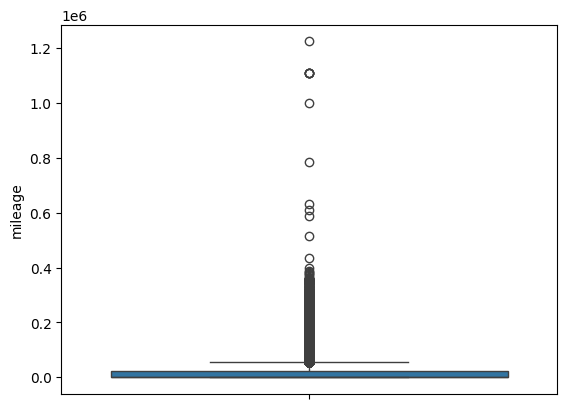

In [578]:
import seaborn as sns

sns.boxplot(y="mileage", data=df_cars)

<Axes: ylabel='horsepower'>

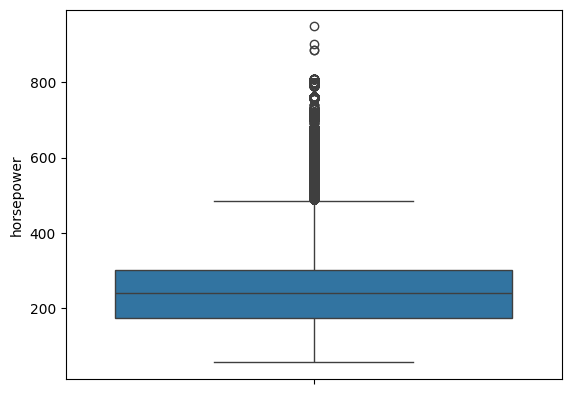

In [579]:
import seaborn as sns 

sns.boxplot(y="horsepower",data=df_cars)

*5.1.2-Univariate Analysis of Qualitative Variables*

C:\Users\louis\AppData\Local\Temp\ipykernel_55992\59298684.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="body_type",data=df_cars, palette="pastel")


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'SUV / Crossover'),
  Text(1, 0, 'Sedan'),
  Text(2, 0, 'Coupe'),
  Text(3, 0, 'Hatchback'),
  Text(4, 0, 'Pickup Truck'),
  Text(5, 0, 'Wagon'),
  Text(6, 0, 'Minivan'),
  Text(7, 0, 'Van'),
  Text(8, 0, 'Convertible')])

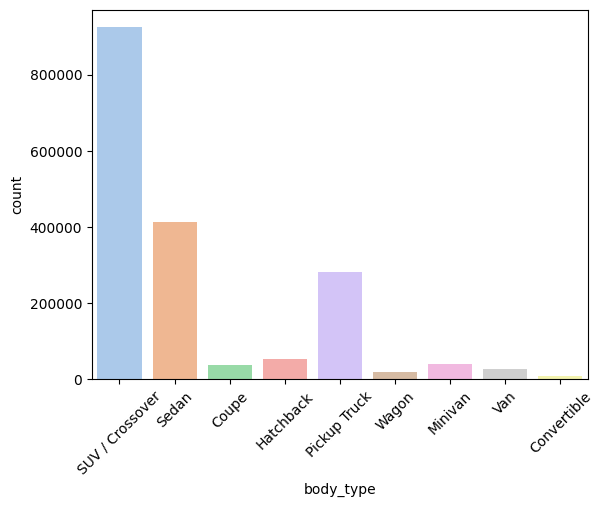

In [580]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.countplot(x="body_type",data=df_cars, palette="pastel")
plt.xticks(rotation=45)

C:\Users\louis\AppData\Local\Temp\ipykernel_55992\432533035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="fuel_type", data=df_cars, palette="pastel")


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Gasoline'),
  Text(1, 0, 'Diesel'),
  Text(2, 0, 'Biodiesel'),
  Text(3, 0, 'Flex Fuel Vehicle'),
  Text(4, 0, 'Electric'),
  Text(5, 0, 'Hybrid'),
  Text(6, 0, 'Compressed Natural Gas'),
  Text(7, 0, 'Propane')])

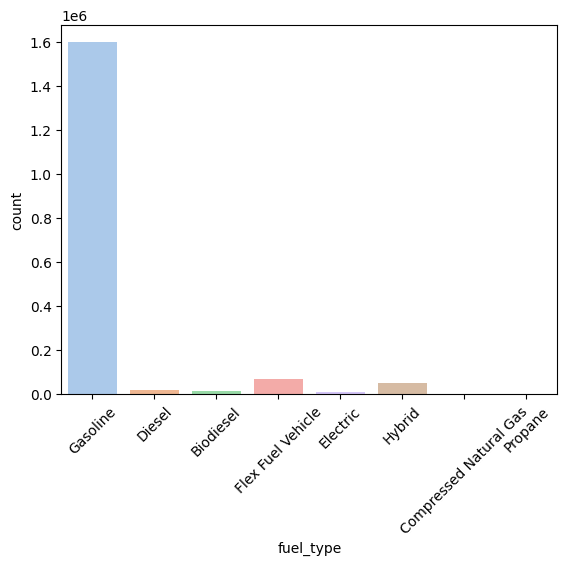

In [581]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.countplot(x="fuel_type", data=df_cars, palette="pastel")
plt.xticks(rotation=45)

C:\Users\louis\AppData\Local\Temp\ipykernel_55992\3868026024.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cars, x="is_new", palette="pastel")


<Axes: xlabel='is_new', ylabel='count'>

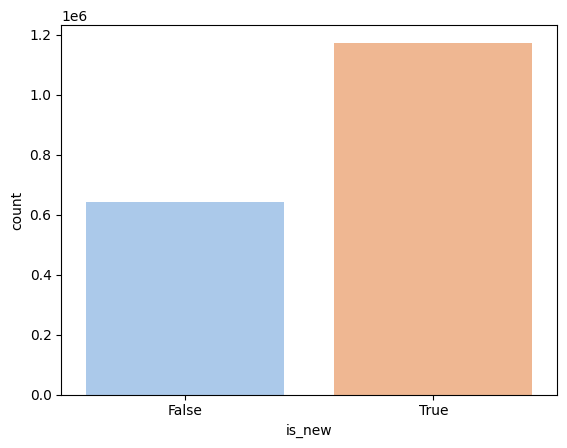

In [582]:
import seaborn as sns 

sns.countplot(data=df_cars, x="is_new", palette="pastel")

C:\Users\louis\AppData\Local\Temp\ipykernel_55992\51160949.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="wheel_system", data=df_cars, palette="pastel")


<Axes: xlabel='wheel_system', ylabel='count'>

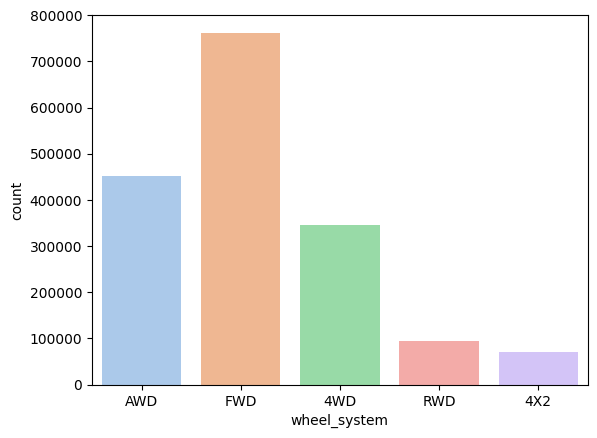

In [583]:
import seaborn as sns 

sns.countplot(x="wheel_system", data=df_cars, palette="pastel")

C:\Users\louis\AppData\Local\Temp\ipykernel_55992\3595533480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="transmission", data=df_cars, palette="pastel")


<Axes: xlabel='transmission', ylabel='count'>

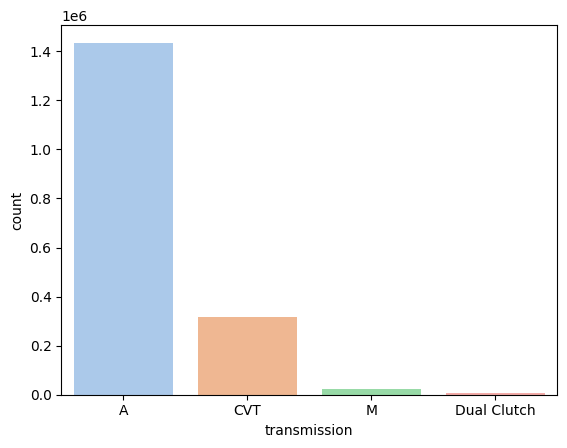

In [584]:
import seaborn as sns 

sns.countplot(x="transmission", data=df_cars, palette="pastel")

*5.2-Bivariate Analysis*

*5.2.1-Bivariate Analysis of Quantitative Variables*

<Axes: xlabel='mileage', ylabel='price'>

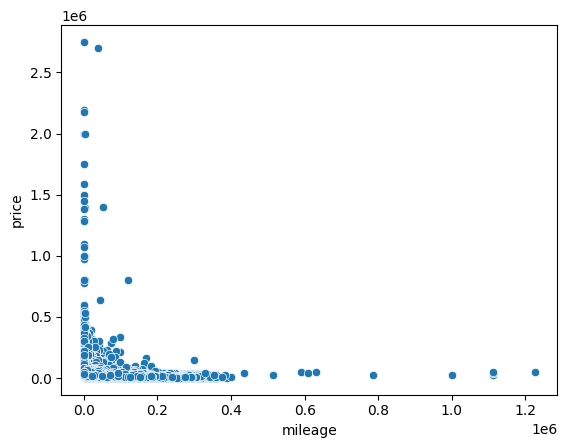

In [585]:
import seaborn as sns 

sns.scatterplot(x="mileage", y="price", data=df_cars,)

<Axes: xlabel='horsepower', ylabel='price'>

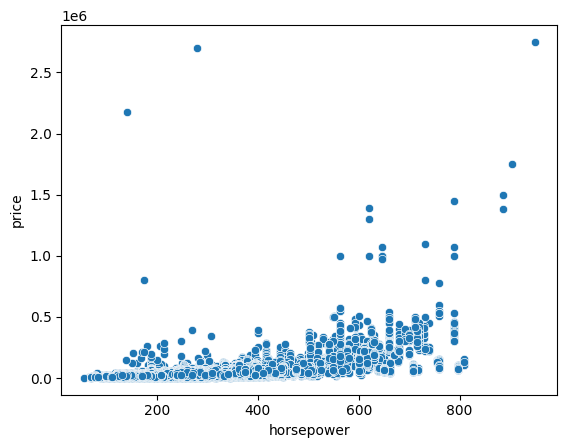

In [586]:
import seaborn as sns 

sns.scatterplot(x="horsepower", y="price", data=df_cars,)

*5.2.2-Bivariate Analysis of Qualitative Variables*

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'SUV / Crossover'),
  Text(1, 0, 'Sedan'),
  Text(2, 0, 'Coupe'),
  Text(3, 0, 'Hatchback'),
  Text(4, 0, 'Pickup Truck'),
  Text(5, 0, 'Wagon'),
  Text(6, 0, 'Minivan'),
  Text(7, 0, 'Van'),
  Text(8, 0, 'Convertible')])

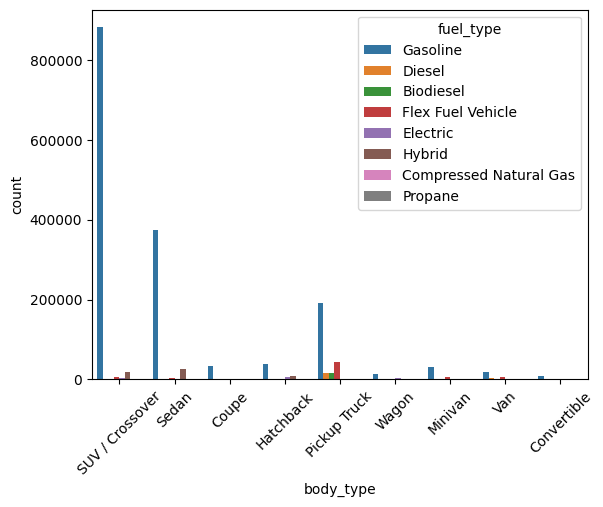

In [587]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="body_type", hue="fuel_type", data=df_cars)
plt.xticks(rotation=45)

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'SUV / Crossover'),
  Text(1, 0, 'Sedan'),
  Text(2, 0, 'Coupe'),
  Text(3, 0, 'Hatchback'),
  Text(4, 0, 'Pickup Truck'),
  Text(5, 0, 'Wagon'),
  Text(6, 0, 'Minivan'),
  Text(7, 0, 'Van'),
  Text(8, 0, 'Convertible')])

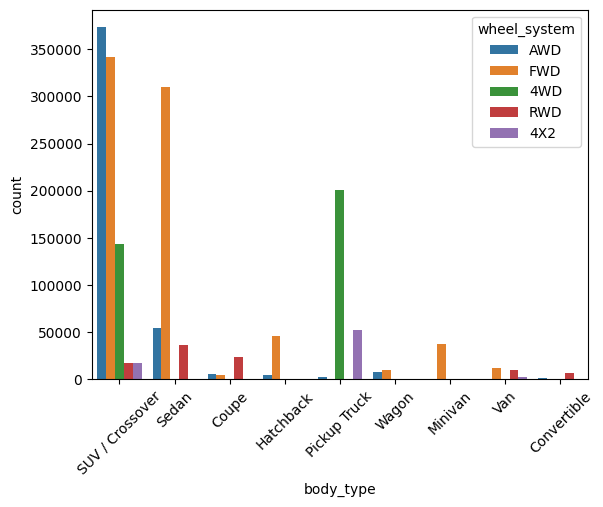

In [588]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="body_type", hue="wheel_system", data=df_cars)
plt.xticks(rotation=45)


*5.2.3-Bivariate Analysis of Quantitative and Qualitative Variables*

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'SUV / Crossover'),
  Text(1, 0, 'Sedan'),
  Text(2, 0, 'Coupe'),
  Text(3, 0, 'Hatchback'),
  Text(4, 0, 'Pickup Truck'),
  Text(5, 0, 'Wagon'),
  Text(6, 0, 'Minivan'),
  Text(7, 0, 'Van'),
  Text(8, 0, 'Convertible')])

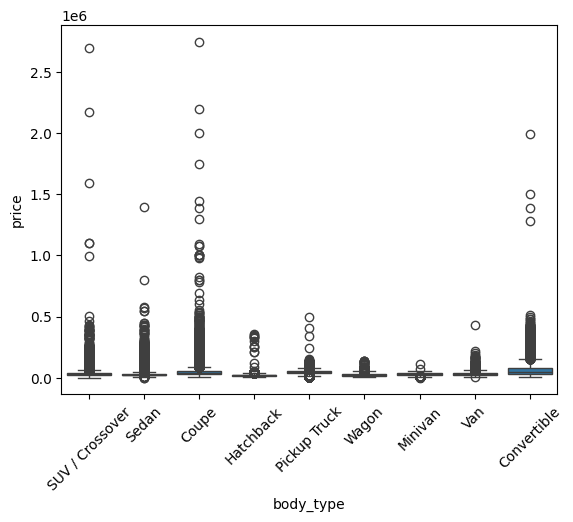

In [589]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="body_type", y="price", data=df_cars)
plt.xticks(rotation=45)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Gasoline'),
  Text(1, 0, 'Diesel'),
  Text(2, 0, 'Biodiesel'),
  Text(3, 0, 'Flex Fuel Vehicle'),
  Text(4, 0, 'Electric'),
  Text(5, 0, 'Hybrid'),
  Text(6, 0, 'Compressed Natural Gas'),
  Text(7, 0, 'Propane')])

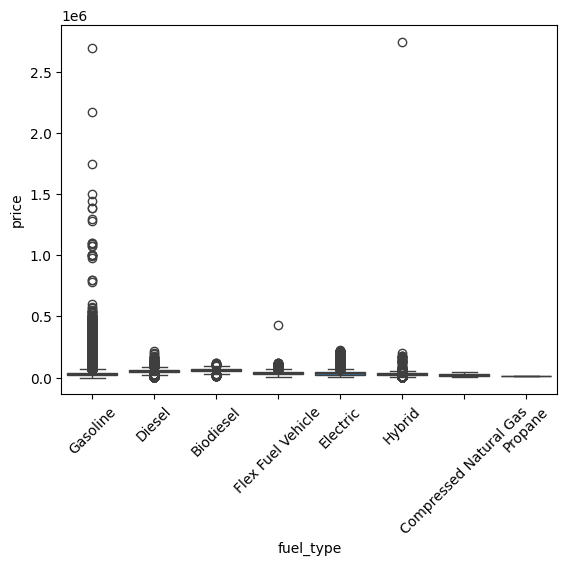

In [590]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.boxplot(x="fuel_type", y="price", data=df_cars,)
plt.xticks(rotation=45)


<Axes: xlabel='wheel_system', ylabel='price'>

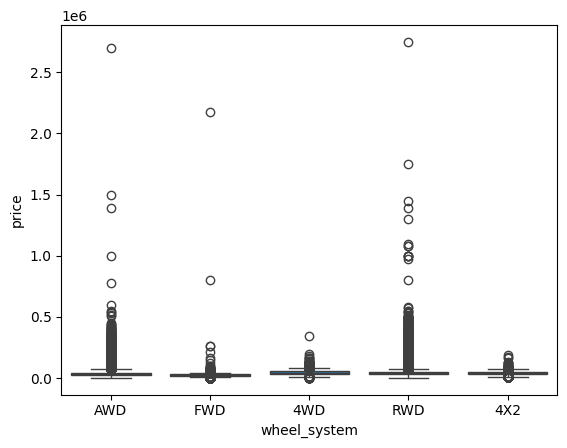

In [591]:
import seaborn as sns 

sns.boxplot(x="wheel_system", y="price", data=df_cars,)

*Step 3 : Data cleaning*

*3.1-Treatment of Missing Values*

In [592]:
missing_columns = missing_values_percentage_overall[missing_values_percentage_overall > 20].index

df_cars = df_cars.drop(columns=missing_columns)

df_cars.head()

,vin,back_legroom,body_type,city,city_fuel_economy,daysonmarket,dealer_zip,description,engine_cylinders,engine_displacement,...,torque,transmission,transmission_display,trimId,trim_name,wheel_system,wheel_system_display,wheelbase,width,year
1,SALCJ2FX1LH858117,38.1 in,SUV / Crossover,San Juan,NaN,207,922,"[!@@Additional Info@@!]Keyless Entry,Ebony Mor...",I4,2000.0,...,"269 lb-ft @ 1,400 RPM",A,9-Speed Automatic Overdrive,t86759,S AWD,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
3,SALRR2RV0L2433391,37.6 in,SUV / Crossover,San Juan,NaN,196,922,"[!@@Additional Info@@!]Fog Lights,7 Seat Packa...",V6,3000.0,...,"332 lb-ft @ 3,500 RPM",A,8-Speed Automatic Overdrive,t86074,V6 HSE AWD,AWD,All-Wheel Drive,115 in,87.4 in,2020
4,SALCJ2FXXLH862327,38.1 in,SUV / Crossover,San Juan,NaN,137,922,"[!@@Additional Info@@!]Keyless Entry,Ebony Mor...",I4,2000.0,...,"269 lb-ft @ 1,400 RPM",A,9-Speed Automatic Overdrive,t86759,S AWD,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
5,SALYK2EX1LA261711,37.1 in,SUV / Crossover,San Juan,NaN,242,922,"[!@@Additional Info@@!]Tires: 21' All-Season,A...",I4,2000.0,...,"269 lb-ft @ 1,200 RPM",A,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,AWD,All-Wheel Drive,113.1 in,84.4 in,2020
7,SALYK2EX5LA275434,37.1 in,SUV / Crossover,San Juan,NaN,70,922,"[!@@Additional Info@@!]Tires: 21' All-Season,A...",I4,2000.0,...,"269 lb-ft @ 1,200 RPM",A,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,AWD,All-Wheel Drive,113.1 in,84.4 in,2020


*3.2-Treatment of Irrelevant Features*

In [593]:
irrelevant_columns = ["vin","listing_id","sp_id","sp_name","description","main_picture_url","dealer_zip","latitude","longitude","listing_color","interior_color","exterior_color","major_options","seller_rating","savings_amount","torque","power","transmission_display","wheel_system_display","trimId","front_legroom","back_legroom","fuel_tank_volume","height","width","wheelbase","engine_cylinders","city","make_name","model_name","trim_name","franchise_make","engine_type", "listed_date"]

df_cars= df_cars.drop(columns=irrelevant_columns)

df_cars.head()

,body_type,city_fuel_economy,daysonmarket,engine_displacement,franchise_dealer,fuel_type,highway_fuel_economy,horsepower,is_new,length,maximum_seating,mileage,price,transmission,wheel_system,year
1,SUV / Crossover,NaN,207,2000.0,True,Gasoline,NaN,246.0,True,181 in,7 seats,8.0,46500.0,A,AWD,2020
3,SUV / Crossover,NaN,196,3000.0,True,Gasoline,NaN,340.0,True,195.1 in,7 seats,11.0,67430.0,A,AWD,2020
4,SUV / Crossover,NaN,137,2000.0,True,Gasoline,NaN,246.0,True,181 in,7 seats,7.0,48880.0,A,AWD,2020
5,SUV / Crossover,NaN,242,2000.0,True,Gasoline,NaN,247.0,True,188.9 in,5 seats,12.0,66903.0,A,AWD,2020
7,SUV / Crossover,NaN,70,2000.0,True,Gasoline,NaN,247.0,True,188.9 in,5 seats,11.0,68520.0,A,AWD,2020


*3.3-Treatment of Inconsistent Values*

*3.3.1-Treatment of Inconsistent Units*

In [594]:
df_cars["length"] = df_cars["length"].str.replace(" in", "", regex=False)
df_cars["maximum_seating"] = df_cars["maximum_seating"].str.replace(" seats", "", regex=False)

*3.4-Treatment of Inconsistent Types*

*3.4.1- Treatment of Inconsistent Numeric*

In [595]:
df_cars["length"] = pd.to_numeric(df_cars["length"], errors="coerce")
df_cars["maximum_seating"] = pd.to_numeric(df_cars["maximum_seating"], errors="coerce")

*Step 4 : Data splitting*

In [596]:
from sklearn.model_selection import train_test_split

df_cars_train, df_cars_test = train_test_split(df_cars,test_size=0.2,random_state=28)

df_cars_train_prepro = df_cars_train.copy()
df_cars_test_prepro = df_cars_test.copy()

*Step 5 : Prepossessing*

*5.1-Feature Imputation*

*5.1.1-Quantitative Feature Imputation*

*Quantitative Imputation 1 : SimpleImputer*

In [597]:
import numpy as np
from sklearn.impute import SimpleImputer

quantitative_columns= df_cars_train_prepro.select_dtypes(include="number").columns

quantitative_imputer = SimpleImputer(missing_values=np.nan,strategy="median")

df_cars_train_prepro[quantitative_columns] = quantitative_imputer.fit_transform(df_cars_train_prepro[quantitative_columns])
df_cars_test_prepro[quantitative_columns] = quantitative_imputer.transform(df_cars_test_prepro[quantitative_columns])

df_cars_train_prepro.head()

,body_type,city_fuel_economy,daysonmarket,engine_displacement,franchise_dealer,fuel_type,highway_fuel_economy,horsepower,is_new,length,maximum_seating,mileage,price,transmission,wheel_system,year
647694,SUV / Crossover,22.0,1.0,2500.0,True,NaN,29.0,240.0,True,189.8,5.0,1.0,54545.0,A,NaN,2021.0
1206467,Pickup Truck,17.0,18.0,3500.0,True,Gasoline,23.0,375.0,False,231.9,6.0,20714.0,41696.0,A,4WD,2018.0
634747,SUV / Crossover,27.0,263.0,1000.0,True,Gasoline,29.0,123.0,True,161.3,5.0,1.0,24545.0,A,FWD,2020.0
2317048,Pickup Truck,17.0,160.0,3600.0,True,Gasoline,22.0,285.0,False,218.0,5.0,3444.0,43281.0,A,4WD,2020.0
146510,SUV / Crossover,26.0,28.0,1800.0,True,Gasoline,31.0,141.0,True,170.9,5.0,1.0,25240.0,CVT,AWD,2020.0


*Quantitative Imputation 2 : KNNImputer*

In [598]:
#from sklearn.impute import KNNImputer

#quantitative_columns= df_cars_train_prepro.select_dtypes(include="number").columns

#quantitative_imputer = KNNImputer(n_neighbors=5)

#df_cars_train_prepro[quantitative_columns] = quantitative_imputer.fit_transform(df_cars_train_prepro[quantitative_columns])
#df_cars_test_prepro[quantitative_columns] = quantitative_imputer.transform(df_cars_train_prepro[quantitative_columns])

#df_cars_train_prepro.head()

*5.1.2-Qualitative Feature Imputation*

*Qualitative Imputation 1 : SimpleImputer*

In [599]:
import numpy as np
from sklearn.impute import SimpleImputer

qualitative_columns= df_cars_train_prepro.select_dtypes(include=["object", "category", "string"]).columns

qualitative_imputer = SimpleImputer(missing_values=np.nan,strategy="most_frequent")

df_cars_train_prepro[qualitative_columns] = qualitative_imputer.fit_transform(df_cars_train_prepro[qualitative_columns])
df_cars_test_prepro[qualitative_columns] = qualitative_imputer.transform(df_cars_test_prepro[qualitative_columns])

df_cars_train_prepro.head()

,body_type,city_fuel_economy,daysonmarket,engine_displacement,franchise_dealer,fuel_type,highway_fuel_economy,horsepower,is_new,length,maximum_seating,mileage,price,transmission,wheel_system,year
647694,SUV / Crossover,22.0,1.0,2500.0,True,Gasoline,29.0,240.0,True,189.8,5.0,1.0,54545.0,A,FWD,2021.0
1206467,Pickup Truck,17.0,18.0,3500.0,True,Gasoline,23.0,375.0,False,231.9,6.0,20714.0,41696.0,A,4WD,2018.0
634747,SUV / Crossover,27.0,263.0,1000.0,True,Gasoline,29.0,123.0,True,161.3,5.0,1.0,24545.0,A,FWD,2020.0
2317048,Pickup Truck,17.0,160.0,3600.0,True,Gasoline,22.0,285.0,False,218.0,5.0,3444.0,43281.0,A,4WD,2020.0
146510,SUV / Crossover,26.0,28.0,1800.0,True,Gasoline,31.0,141.0,True,170.9,5.0,1.0,25240.0,CVT,AWD,2020.0


*5.2-Feature Engineering*

*5.2.1-Feature Creation*

*Variable Creation 1 : car_age_creation*

In [600]:
df_cars_train_prepro["car_age_creation"] = 2024 - df_cars_train_prepro["year"]
df_cars_test_prepro["car_age_creation"] = 2024 - df_cars_test_prepro["year"]

df_cars_train_prepro.head()

,body_type,city_fuel_economy,daysonmarket,engine_displacement,franchise_dealer,fuel_type,highway_fuel_economy,horsepower,is_new,length,maximum_seating,mileage,price,transmission,wheel_system,year,car_age_creation
647694,SUV / Crossover,22.0,1.0,2500.0,True,Gasoline,29.0,240.0,True,189.8,5.0,1.0,54545.0,A,FWD,2021.0,3.0
1206467,Pickup Truck,17.0,18.0,3500.0,True,Gasoline,23.0,375.0,False,231.9,6.0,20714.0,41696.0,A,4WD,2018.0,6.0
634747,SUV / Crossover,27.0,263.0,1000.0,True,Gasoline,29.0,123.0,True,161.3,5.0,1.0,24545.0,A,FWD,2020.0,4.0
2317048,Pickup Truck,17.0,160.0,3600.0,True,Gasoline,22.0,285.0,False,218.0,5.0,3444.0,43281.0,A,4WD,2020.0,4.0
146510,SUV / Crossover,26.0,28.0,1800.0,True,Gasoline,31.0,141.0,True,170.9,5.0,1.0,25240.0,CVT,AWD,2020.0,4.0


*5.2.2-Feature Transformation*

*Variable Transformation 1 : log_mileage_transformation*

In [601]:
import numpy as np

df_cars_train_prepro["log_mileage_transformation"] = np.log1p(df_cars_train_prepro["mileage"])
df_cars_test_prepro["log_mileage_transformation"] = np.log1p(df_cars_test_prepro["mileage"])

df_cars_train_prepro.head()

,body_type,city_fuel_economy,daysonmarket,engine_displacement,franchise_dealer,fuel_type,highway_fuel_economy,horsepower,is_new,length,maximum_seating,mileage,price,transmission,wheel_system,year,car_age_creation,log_mileage_transformation
647694,SUV / Crossover,22.0,1.0,2500.0,True,Gasoline,29.0,240.0,True,189.8,5.0,1.0,54545.0,A,FWD,2021.0,3.0,0.693147
1206467,Pickup Truck,17.0,18.0,3500.0,True,Gasoline,23.0,375.0,False,231.9,6.0,20714.0,41696.0,A,4WD,2018.0,6.0,9.938613
634747,SUV / Crossover,27.0,263.0,1000.0,True,Gasoline,29.0,123.0,True,161.3,5.0,1.0,24545.0,A,FWD,2020.0,4.0,0.693147
2317048,Pickup Truck,17.0,160.0,3600.0,True,Gasoline,22.0,285.0,False,218.0,5.0,3444.0,43281.0,A,4WD,2020.0,4.0,8.144679
146510,SUV / Crossover,26.0,28.0,1800.0,True,Gasoline,31.0,141.0,True,170.9,5.0,1.0,25240.0,CVT,AWD,2020.0,4.0,0.693147


*5.2.3-Feature Extraction*

In [602]:
#on peut le faire si on en a envie ...

*5.2.4-Feature Interaction*

*Variable Interaction 1 : power_per_displacement_interaction*

In [603]:
df_cars_train_prepro["power_per_displacement_interaction"] = (df_cars_train_prepro["horsepower"] / df_cars_train_prepro["engine_displacement"])
df_cars_test_prepro["power_per_displacement_interaction"] = (df_cars_test_prepro["horsepower"] / df_cars_test_prepro["engine_displacement"])

df_cars_train_prepro.head()

,body_type,city_fuel_economy,daysonmarket,engine_displacement,franchise_dealer,fuel_type,highway_fuel_economy,horsepower,is_new,length,maximum_seating,mileage,price,transmission,wheel_system,year,car_age_creation,log_mileage_transformation,power_per_displacement_interaction
647694,SUV / Crossover,22.0,1.0,2500.0,True,Gasoline,29.0,240.0,True,189.8,5.0,1.0,54545.0,A,FWD,2021.0,3.0,0.693147,0.096000
1206467,Pickup Truck,17.0,18.0,3500.0,True,Gasoline,23.0,375.0,False,231.9,6.0,20714.0,41696.0,A,4WD,2018.0,6.0,9.938613,0.107143
634747,SUV / Crossover,27.0,263.0,1000.0,True,Gasoline,29.0,123.0,True,161.3,5.0,1.0,24545.0,A,FWD,2020.0,4.0,0.693147,0.123000
2317048,Pickup Truck,17.0,160.0,3600.0,True,Gasoline,22.0,285.0,False,218.0,5.0,3444.0,43281.0,A,4WD,2020.0,4.0,8.144679,0.079167
146510,SUV / Crossover,26.0,28.0,1800.0,True,Gasoline,31.0,141.0,True,170.9,5.0,1.0,25240.0,CVT,AWD,2020.0,4.0,0.693147,0.078333


*5.2.5-Feature Binning*

*Variable Binning 1 : year_binning*

In [604]:
df_cars_train_prepro["year_binning"] = pd.cut(df_cars_train_prepro["year"],bins=[1915, 1970, 1990, 2010, 2021],labels=["very_old", "old", "moderate", "recent"], include_lowest=True)

df_cars_test_prepro["year_binning"] = pd.cut(df_cars_test_prepro["year"],bins=[1915, 1970, 1990, 2010, 2021],labels=["very_old", "old", "moderate", "recent"], include_lowest=True)

df_cars_train_prepro.head()

,body_type,city_fuel_economy,daysonmarket,engine_displacement,franchise_dealer,fuel_type,highway_fuel_economy,horsepower,is_new,length,maximum_seating,mileage,price,transmission,wheel_system,year,car_age_creation,log_mileage_transformation,power_per_displacement_interaction,year_binning
647694,SUV / Crossover,22.0,1.0,2500.0,True,Gasoline,29.0,240.0,True,189.8,5.0,1.0,54545.0,A,FWD,2021.0,3.0,0.693147,0.096000,recent
1206467,Pickup Truck,17.0,18.0,3500.0,True,Gasoline,23.0,375.0,False,231.9,6.0,20714.0,41696.0,A,4WD,2018.0,6.0,9.938613,0.107143,recent
634747,SUV / Crossover,27.0,263.0,1000.0,True,Gasoline,29.0,123.0,True,161.3,5.0,1.0,24545.0,A,FWD,2020.0,4.0,0.693147,0.123000,recent
2317048,Pickup Truck,17.0,160.0,3600.0,True,Gasoline,22.0,285.0,False,218.0,5.0,3444.0,43281.0,A,4WD,2020.0,4.0,8.144679,0.079167,recent
146510,SUV / Crossover,26.0,28.0,1800.0,True,Gasoline,31.0,141.0,True,170.9,5.0,1.0,25240.0,CVT,AWD,2020.0,4.0,0.693147,0.078333,recent


*5.3-Feature Encoding*

*5.3.1-Nominal Feature Encoding*

*Nominal Encoding 1 : OneHotEncoder*

In [605]:
from sklearn.preprocessing import OneHotEncoder

qualitative_columns = df_cars_train_prepro.select_dtypes(include=["object","category","string"]).columns
qualitative_columns_nominals = ["body_type", "fuel_type","transmission", "wheel_system"]

encoder_nominal = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

encoded_train = encoder_nominal.fit_transform(df_cars_train_prepro[qualitative_columns_nominals])
encoded_test = encoder_nominal.transform(df_cars_test_prepro[qualitative_columns_nominals])

df_cars_train_prepro = df_cars_train_prepro.drop(columns=qualitative_columns_nominals).join(encoded_train)
df_cars_test_prepro = df_cars_test_prepro.drop(columns=qualitative_columns_nominals).join(encoded_test)

df_cars_train_prepro.head()

,city_fuel_economy,daysonmarket,engine_displacement,franchise_dealer,highway_fuel_economy,horsepower,is_new,length,maximum_seating,mileage,...,fuel_type_Propane,transmission_A,transmission_CVT,transmission_Dual Clutch,transmission_M,wheel_system_4WD,wheel_system_4X2,wheel_system_AWD,wheel_system_FWD,wheel_system_RWD
647694,22.0,1.0,2500.0,True,29.0,240.0,True,189.8,5.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1206467,17.0,18.0,3500.0,True,23.0,375.0,False,231.9,6.0,20714.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
634747,27.0,263.0,1000.0,True,29.0,123.0,True,161.3,5.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2317048,17.0,160.0,3600.0,True,22.0,285.0,False,218.0,5.0,3444.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
146510,26.0,28.0,1800.0,True,31.0,141.0,True,170.9,5.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


*Nominal Encoding 2 : Get dummies*

In [606]:
#import pandas as pd

#qualitative_columns = df_cars_train_prepro.select_dtypes(include=["object","category","string"]).columns
#qualitative_columns_nominals = ["body_type", "city", "engine_type","franchise_make", "fuel_type", "make_name", "model_name","transmission", "trim_name", "wheel_system"]

#df_cars_train_prepro = pd.get_dummies(df_cars_train_prepro, columns=qualitative_columns_nominals, dtype=int)
#df_cars_test_prepro = pd.get_dummies(df_cars_test_prepro, columns=qualitative_columns_nominals, dtype=int)

#df_cars_train_prepro.head()

*5.3.2-Ordinal Feature Encoding*

*Ordinal Encoding 1 : OrdinalEncoder*

*Ici on a pas de variables ordinales dans notre dataset, peut etre il faut en créer au moins une !*

In [607]:
from sklearn.preprocessing import OrdinalEncoder

qualitative_columns = df_cars_train_prepro.select_dtypes(include=["object","category","string"]).columns
qualitative_columns_ordinals = ["year_binning"]

encoder_ordinal = OrdinalEncoder().set_output(transform="pandas")

encoded_train = encoder_ordinal.fit_transform(df_cars_train_prepro[qualitative_columns_ordinals])
encoded_test = encoder_ordinal.transform(df_cars_test_prepro[qualitative_columns_ordinals])

df_cars_train_prepro = df_cars_train_prepro.drop(columns=qualitative_columns_ordinals).join(encoded_train)
df_cars_test_prepro = df_cars_test_prepro.drop(columns=qualitative_columns_ordinals).join(encoded_test)

df_cars_train_prepro.head()

,city_fuel_economy,daysonmarket,engine_displacement,franchise_dealer,highway_fuel_economy,horsepower,is_new,length,maximum_seating,mileage,...,transmission_A,transmission_CVT,transmission_Dual Clutch,transmission_M,wheel_system_4WD,wheel_system_4X2,wheel_system_AWD,wheel_system_FWD,wheel_system_RWD,year_binning
647694,22.0,1.0,2500.0,True,29.0,240.0,True,189.8,5.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
1206467,17.0,18.0,3500.0,True,23.0,375.0,False,231.9,6.0,20714.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0
634747,27.0,263.0,1000.0,True,29.0,123.0,True,161.3,5.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
2317048,17.0,160.0,3600.0,True,22.0,285.0,False,218.0,5.0,3444.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0
146510,26.0,28.0,1800.0,True,31.0,141.0,True,170.9,5.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0


*5.4-Feature Scaling*

*Scaling 1 : StandardScaler*

In [608]:
from sklearn.preprocessing import StandardScaler

quantitative_columns=df_cars_train_prepro.select_dtypes(include="number").columns

scaler_standard = StandardScaler()

df_cars_train_prepro[quantitative_columns] = scaler_standard.fit_transform(df_cars_train_prepro[quantitative_columns])
df_cars_test_prepro[quantitative_columns] = scaler_standard.transform(df_cars_test_prepro[quantitative_columns])

df_cars_train_prepro.head()

,city_fuel_economy,daysonmarket,engine_displacement,franchise_dealer,highway_fuel_economy,horsepower,is_new,length,maximum_seating,mileage,...,transmission_A,transmission_CVT,transmission_Dual Clutch,transmission_M,wheel_system_4WD,wheel_system_4X2,wheel_system_AWD,wheel_system_FWD,wheel_system_RWD,year_binning
647694,-0.133283,-0.885395,-0.257209,True,-0.110025,-0.066894,True,-0.158921,-0.396696,-0.502024,...,0.48429,-0.459396,-0.06254,-0.109351,-0.484871,-0.202076,-0.575347,1.063072,-0.23483,0.106996
1206467,-0.706900,-0.686902,0.532814,True,-0.916072,1.464028,False,1.981386,0.530881,0.224319,...,0.48429,-0.459396,-0.06254,-0.109351,2.062406,-0.202076,-0.575347,-0.940670,-0.23483,0.106996
634747,0.440334,2.173730,-1.442243,True,-0.110025,-1.393692,True,-1.607821,-0.396696,-0.502024,...,0.48429,-0.459396,-0.06254,-0.109351,-0.484871,-0.202076,-0.575347,1.063072,-0.23483,0.106996
2317048,-0.706900,0.971097,0.611816,True,-1.050413,0.443413,False,1.274729,-0.396696,-0.381288,...,0.48429,-0.459396,-0.06254,-0.109351,2.062406,-0.202076,-0.575347,-0.940670,-0.23483,0.106996
146510,0.325611,-0.570142,-0.810225,True,0.158657,-1.189570,True,-1.119771,-0.396696,-0.502024,...,-2.06488,2.176769,-0.06254,-0.109351,-0.484871,-0.202076,1.738082,-0.940670,-0.23483,0.106996


*Scaling 2 : MinMaxScaler*

In [609]:
#from sklearn.preprocessing import MinMaxScaler

#quantitative_columns=df_cars_train_prepro.select_dtypes(include="number").columns

#scaler_minmax = MinMaxScaler()

#df_cars_train_prepro[quantitative_columns] = scaler_minmax.fit_transform(df_cars_train_prepro[quantitative_columns])
#df_cars_test_prepro[quantitative_columns] = scaler_minmax.transform(df_cars_test_prepro[quantitative_columns])

#df_cars_train_prepro.head()

*Scaling 3 : RobustScaler*

In [610]:
#from sklearn.preprocessing import RobustScaler

#quantitative_columns=df_cars_train_prepro.select_dtypes(include="number").columns

#scaler_robust = RobustScaler()

#df_cars_train_prepro[quantitative_columns] = scaler_robust.fit_transform(df_cars_train_prepro[quantitative_columns])
#df_cars_test_prepro[quantitative_columns] = scaler_robust.transform(df_cars_test_prepro[quantitative_columns])

#df_cars_train_prepro.head()

*Step 6 : Modeling*


*6.1- Model Preparation*

In [611]:
X_train = df_cars_train_prepro.drop("price", axis=1)
y_train = df_cars_train_prepro["price"]

X_test = df_cars_test_prepro.drop("price", axis=1)
y_test = df_cars_test_prepro["price"]

*6.2 – Model Training*

In [612]:
X_train.isna().sum().sort_values(ascending=False).head(30)

city_fuel_economy                     0
daysonmarket                          0
engine_displacement                   0
franchise_dealer                      0
highway_fuel_economy                  0
horsepower                            0
is_new                                0
length                                0
maximum_seating                       0
mileage                               0
year                                  0
car_age_creation                      0
log_mileage_transformation            0
power_per_displacement_interaction    0
body_type_Convertible                 0
body_type_Coupe                       0
body_type_Hatchback                   0
body_type_Minivan                     0
body_type_Pickup Truck                0
body_type_SUV / Crossover             0
body_type_Sedan                       0
body_type_Van                         0
body_type_Wagon                       0
fuel_type_Biodiesel                   0
fuel_type_Compressed Natural Gas      0


In [613]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


*4.2 – Model Evaluation*

In [614]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 0.3376770286865956
RMSE : 0.5948801802055919
R2 : 0.609897679609221
